In [1]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : House Price Prediction (Regression)
Algorithm       : Multi-Layer Perceptron (MLP) with LMS Cost Function – from scratch

Description     : Manual implementation of a Multi-Layer Perceptron for regression 
                  using Least Mean Squares (LMS) / Gradient Descent.
                  Supports 2-hidden-layer architectures.
                  Part of the comprehensive Deep Learning course.

Full video course (theory + equations + step-by-step implementation):
https://onlinebme.com/
https://onlinebme.com/product/implementing-neural-networks-with-pytorch/
============================================================================
"""

'\n============================================================================\nAuthor          : Mohammad Norizadeh Cherloo\nWebsite         : https://onlinebme.com/\nGitHub          : https://github.com/Mohammad-Norizadeh-Cherloo\nGoogle Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ\n\nProject         : House Price Prediction (Regression)\nAlgorithm       : Multi-Layer Perceptron (MLP) with LMS Cost Function – from scratch\n\nDescription     : Manual implementation of a Multi-Layer Perceptron for regression \n                  using Least Mean Squares (LMS) / Gradient Descent.\n                  Supports 2-hidden-layer architectures.\n                  Part of the comprehensive Deep Learning course.\n\nFull video course (theory + equations + step-by-step implementation):\nhttps://onlinebme.com/\nhttps://onlinebme.com/product/implementing-neural-networks-with-pytorch/\n============================================================================\n'

In [2]:
import torch
from sklearn import metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## **Neural Network Classes (from scratch)**

In [3]:
class MLP_Regressor():
     def __init__(self,n_features,n_hidden1,n_hidden2,n_out,lr=0.1,wrate=1):
          self.w1= torch.randn(n_hidden1,n_features+1)*wrate
          self.w2= torch.randn(n_hidden2,n_hidden1+1)*wrate
          self.w3= torch.randn(n_out,n_hidden2+1)*wrate
          self.lr= lr
          self.n_features=n_features
          self.n_hidden1=n_hidden1
          self.n_hidden2=n_hidden2
          self.n_out=n_out
          
     def __call__(self, data):
          y_pred= self.forward(data)
          return y_pred
              
     def forward(self,data):
          w1= self.w1
          w2= self.w2
          w3= self.w3
          # add bias
          data= torch.cat((-torch.ones(data.size(0),1),data),dim=1) 
          # farward pass
          v1= torch.matmul(w1,data.T)# (2x3) x (3x1) = 2x1
          y1= torch.tanh(v1)
          # add bias
          y1= torch.cat((-torch.ones(1,y1.size(1)),y1),dim=0)
          
          v2= torch.matmul(w2,y1)
          y2= torch.tanh(v2)
          # add bias
          y2= torch.cat((-torch.ones(1,y2.size(1)),y2),dim=0)
          
          v3= torch.matmul(w3,y2)#noutxn_sample
          y3= torch.relu(v3)
          ypred= y3
          
          self.y1=y1
          self.y2= y2
          self.y3= y3
          self.input= data  
          return ypred 
     
     def backward(self,y_true,y_pred):
          lr= self.lr
          w1= self.w1
          w2= self.w2
          w3= self.w3
          input= self.input
          y1= self.y1
          y2= self.y2
          y3= self.y3
          
          y_true= y_true.T
          e= y_true-y_pred
          # adjust output layer weights
          gd3= self.g_relu(y3)
          delta3= e*(gd3)
          dw3= lr*torch.matmul(delta3,y2.T) 
          w3= w3+dw3  
          # adjust hidden layer weights
          gd2= self.g_tanh(y2)
          delta2= (gd2) * torch.matmul(w3.T,delta3)
          delta2= delta2[1:,:] 
          dw2= lr*torch.matmul(delta2,y1.T) 
          w2= w2+dw2
          
          gd1= self.g_tanh(y1)
          delta1= (gd1) * torch.matmul(w2.T,delta2)
          delta1= delta1[1:,:] 
          dw1= lr*torch.matmul(delta1,input) 
          w1= w1+dw1
          
          self.w1= w1
          self.w2= w2
          self.w3= w3
     
     def mse(self,y_true,y_pred):
          y_true= y_true.T
          e= y_true-y_pred
          return torch.mean(e**2)
     
     def g_tanh(self,y):
          return (1-y**2)
     
     def g_sigmoid(self,y):
          return y*(1-y)
     
     def g_relu(self,y):
          yhat= (y>0).type(torch.float32)
          return yhat
     
     def g_linear(self,y):
          return torch.ones(y.size())

**Load and Preprocess Data**

In [4]:
# Load dataset
ds_train = pd.read_csv('house/housing_train.txt', header=None, delimiter=r'\s+')
data_train = ds_train.iloc[:, :-1].values
d_train = ds_train.iloc[:, -1].to_numpy()

ds_test = pd.read_csv('house/housing_test.txt', header=None, delimiter=r'\s+')
data_test = ds_test.iloc[:, :-1].values
d_test = ds_test.iloc[:, -1].to_numpy()

# Standardize
scaler = prep.StandardScaler()
data_train = scaler.fit_transform(data_train)
data_test = scaler.transform(data_test)

# Convert to tensor
data_train = torch.from_numpy(data_train).float()
d_train = torch.from_numpy(d_train).float()
data_test = torch.from_numpy(data_test).float()
d_test = torch.from_numpy(d_test).float()

# DataLoader
train_loader = DataLoader(TensorDataset(data_train, d_train), batch_size=32, shuffle=True)

print("Data loaded successfully!")
print(f"Train samples: {data_train.shape[0]}")
print(f"Test samples : {data_test.shape[0]}")
print(f"Features     : {data_train.shape[1]}")

Data loaded successfully!
Train samples: 433
Test samples : 74
Features     : 13


**Train the Network** 

MSE(0): 324.079345703125
MSE(50): 5.318699836730957
MSE(100): 3.8071208000183105
MSE(150): 3.1704418659210205
MSE(200): 2.6231486797332764
MSE(250): 2.2735228538513184
MSE(300): 2.197336435317993
MSE(350): 1.7093315124511719


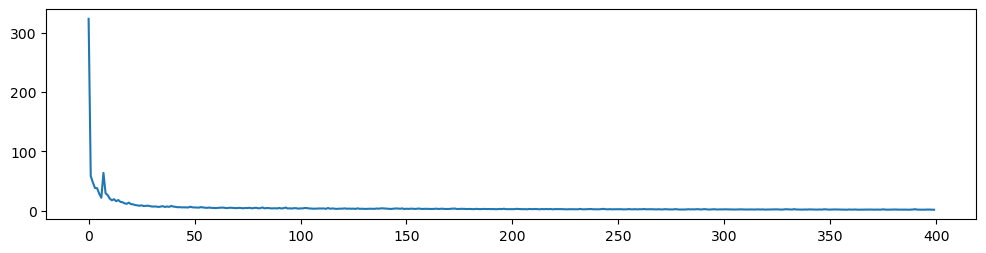

In [6]:
torch.manual_seed(0)
# MLP
lr=0.001
n_out= 1
n_hid1= 20
n_hid2= 10
n_features= data_train.size(1)
mdl= MLP_Regressor(n_features, n_hid1,n_hid2,n_out,lr,wrate=0.01)
#******************************************************************
cost=[]
epoch=400
for iter in range(epoch):
     er=[]
     for xbatch,ybatch in train_loader:
          # farward pass
          ypred= mdl(xbatch)
          # backward pass 
          mdl.backward(ybatch,ypred) 
          er.append(mdl.mse(ybatch,ypred)) 

     loss= torch.mean(torch.tensor(er))
     cost.append(loss)
     if iter%50==0:
          print(f'MSE({iter}): {cost[iter]}')

cost=torch.tensor(cost)
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(cost)
plt.show()

**Evaluate + Plot**

========== Test Results ==========
MSE  : 17.7835
MAE  : 3.0372
R²   : 0.5740
Corr : 0.8035


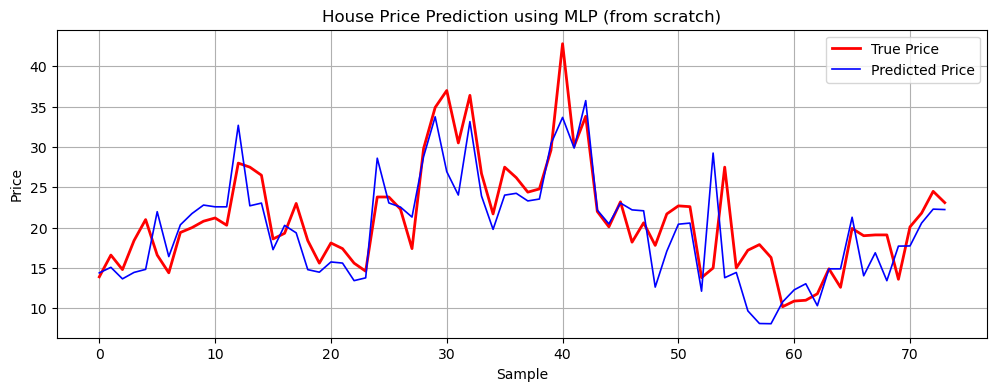

In [7]:
# Prediction
y_pred = mdl(data_test).flatten()
y_true = d_test.flatten()

# Metrics
MSE = metrics.mean_squared_error(y_true, y_pred)
MAE = metrics.mean_absolute_error(y_true, y_pred)
R2  = metrics.r2_score(y_true, y_pred)
Corr = torch.corrcoef(torch.stack((y_true, y_pred)))[0, 1].item()

print("========== Test Results ==========")
print(f"MSE  : {MSE:.4f}")
print(f"MAE  : {MAE:.4f}")
print(f"R²   : {R2:.4f}")
print(f"Corr : {Corr:.4f}")

# Plot
plt.figure(figsize=(12, 4))
plt.plot(y_true.numpy(), 'r', linewidth=2, label='True Price')
plt.plot(y_pred.numpy(), 'b', linewidth=1.2, label='Predicted Price')
plt.title("House Price Prediction using MLP (from scratch)")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()